# NA handling, Plots, PCA, and permutation test

### Author: Rory Gardner

# NA handling

In [ ]:
import pandas as pd
import numpy as np

mobility = pd.read_csv("data/va_mobility.csv")
mobility['date'] = pd.to_datetime(mobility['date'])

na_ratio = mobility.isna().mean()
print(na_ratio)

: 

In [5]:
# mobility feats
features = [
    'retail_and_recreation_percent_change_from_baseline', 
    'grocery_and_pharmacy_percent_change_from_baseline', 
    'parks_percent_change_from_baseline', 
    'transit_stations_percent_change_from_baseline', 
    'workplaces_percent_change_from_baseline', 
    'residential_percent_change_from_baseline'
]

# nonmetro counties (bls)
rural_counties = ["Accomack County","Alleghany County","Bath County",
                  "Bland County","Brunswick County","Buchanan County",
                  "Carroll County","Charlotte County","Craig County",
                  "Dickenson County","Essex County","Grayson County",
                  "Greensville County","Halifax County","Henry County",
                  "Highland County","Lee County","Louisa County",
                  "Lunenburg County","Madison County","Mecklenburg County",
                  "Middlesex County","Montgomery County","Nelson County",
                  "Northampton County","Northumberland County","Patrick County",
                  "Pittsylvania County","Prince Edward County","Pulaski County",
                  "Richmond County","Rockbridge County","Rockingham County",
                  "Russell County","Smyth County","Southampton County",
                  "Tazewell County","Wise County","Wythe County","Shenandoah County"] # from BLS

mobility['metro_label'] = np.where(mobility['sub_region_2'].isin(rural_counties), 0, 1) # add metro label

In [6]:
# only keep features with <30%  NA
features_keep = [f for f in features if mobility[f].notna().mean() > 0.3]

print("keeping features:", features_keep)

keeping features: ['retail_and_recreation_percent_change_from_baseline', 'grocery_and_pharmacy_percent_change_from_baseline', 'transit_stations_percent_change_from_baseline', 'workplaces_percent_change_from_baseline', 'residential_percent_change_from_baseline']


In [7]:
# impute NA
mobility_filled = (
    mobility
    .sort_values(['sub_region_2', 'date'])
    .groupby('sub_region_2', group_keys=False)
    .apply(lambda df: df[features_keep].interpolate(limit_direction='both')
                          .ffill() # forward fill
                          .bfill() # backward fill
                          .assign(metro_label=df['metro_label'], date=df['date'], sub_region_2=df['sub_region_2']))
)

/var/folders/lv/9m_qv53944x04_1mpk21jgtc0000gn/T/ipykernel_39386/2689573426.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: df[features_keep].interpolate(limit_direction='both')


In [8]:
# category with maximum number of na per county
county_max_missing = mobility_filled.groupby('sub_region_2')[features_keep].apply(lambda df: df.isna().mean().max())

# keep if missing less than 70%
counties_keep = county_max_missing[county_max_missing < 0.7].index
mobility_clean = mobility_filled[mobility_filled['sub_region_2'].isin(counties_keep)]

In [9]:

print(len(mobility_clean['sub_region_2'].unique()))
print(mobility_clean[features_keep].isna().sum())

print(mobility_clean['metro_label'].sum()/len(mobility_clean))

53
retail_and_recreation_percent_change_from_baseline    0
grocery_and_pharmacy_percent_change_from_baseline     0
transit_stations_percent_change_from_baseline         0
workplaces_percent_change_from_baseline               0
residential_percent_change_from_baseline              0
dtype: int64
0.8504166991198692


In [10]:
mobility_clean.to_csv("data/mobility_clean.csv", index=False)# write csv

# Line plots: Statewide, Metro, and Nonmetro trends



In [11]:
# data

import matplotlib.pyplot as plt
import seaborn as sns

mobility = pd.read_csv("data/mobility_clean.csv")
mobility['date'] = pd.to_datetime(mobility['date'])

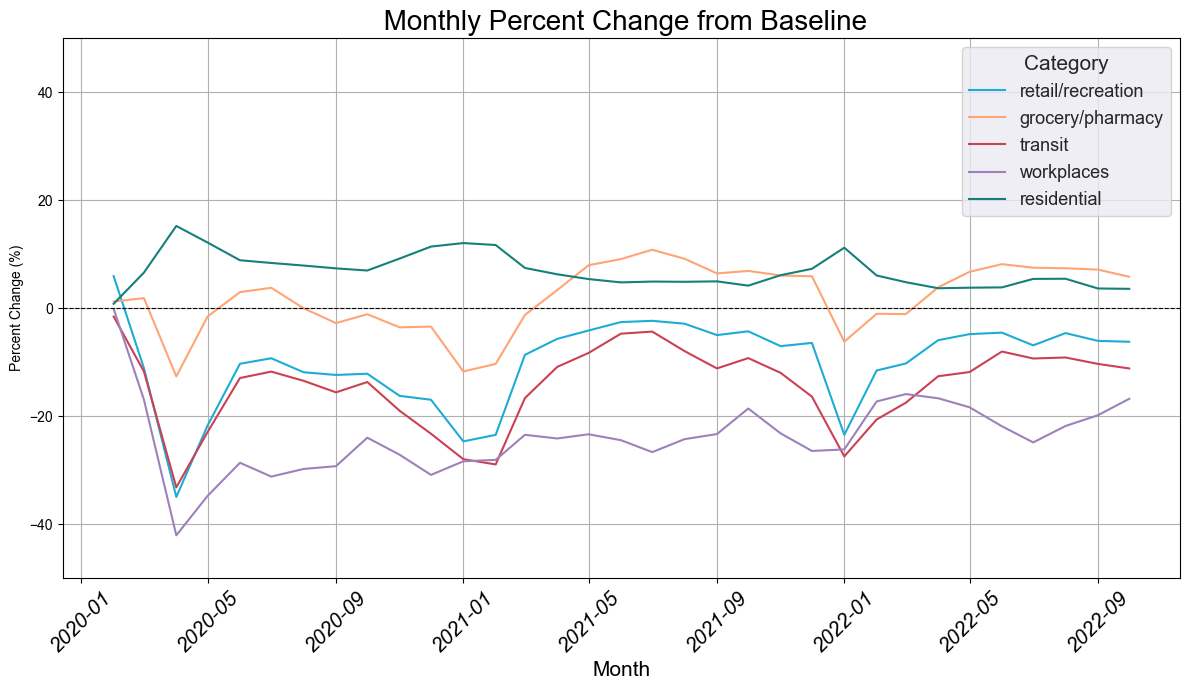

In [12]:
# overall cat trends

mobility_cats = mobility.copy()
mobility_cats["year_month"] = mobility_cats["date"].dt.to_period('M')


cat_cols = [
    "retail_and_recreation_percent_change_from_baseline", 
    "grocery_and_pharmacy_percent_change_from_baseline", 
    "transit_stations_percent_change_from_baseline", 
    "workplaces_percent_change_from_baseline", 
    "residential_percent_change_from_baseline"
]
monthly_mob = mobility_cats.groupby("year_month")[cat_cols].mean()
monthly_mob.index = monthly_mob.index.to_timestamp()

monthly_mob_long = (
    monthly_mob
    .reset_index()
    .melt(id_vars="year_month", value_vars=cat_cols,
          var_name="category", value_name="percent_change")
)

monthly_mob_long["category_short"] = monthly_mob_long["category"].replace({
    "retail_and_recreation_percent_change_from_baseline":"retail/recreation", 
    "grocery_and_pharmacy_percent_change_from_baseline":"grocery/pharmacy", 
    "transit_stations_percent_change_from_baseline":"transit", 
    "workplaces_percent_change_from_baseline":"workplaces", 
    "residential_percent_change_from_baseline":"residential"
    }
)

palette = sns.crayon_palette(["Cerulean", "Atomic Tangerine", "Brick Red", "Purple Mountains' Majesty", "Pine Green"])

fig, ax = plt.subplots(figsize=(12, 7))
sns.lineplot(
    data=monthly_mob_long, 
    x="year_month", 
    y="percent_change", 
    hue="category_short", palette=palette
)

sns.set_style(style="darkgrid")
ax.legend(title="Category", loc="upper right", fontsize=13, title_fontsize=15)


ax.set_title(" Monthly Percent Change from Baseline", fontsize=20)
ax.set_xlabel("Month", fontsize=15)
ax.set_ylabel("Percent Change (%)")
ax.grid(True) 
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.xticks(rotation=45, fontsize=15, style='italic')

plt.ylim(-50, 50)
plt.tight_layout() 
plt.show()


In [13]:
# rural v urban
rural_counties = ["Accomack County","Alleghany County","Bath County",
                  "Bland County","Brunswick County","Buchanan County",
                  "Carroll County","Charlotte County","Craig County",
                  "Dickenson County","Essex County","Grayson County",
                  "Greensville County","Halifax County","Henry County",
                  "Highland County","Lee County","Louisa County",
                  "Lunenburg County","Madison County","Mecklenburg County",
                  "Middlesex County","Montgomery County","Nelson County",
                  "Northampton County","Northumberland County","Patrick County",
                  "Pittsylvania County","Prince Edward County","Pulaski County",
                  "Richmond County","Rockbridge County","Rockingham County",
                  "Russell County","Smyth County","Southampton County",
                  "Tazewell County","Wise County","Wythe County","Shenandoah County"]

rural_mobility = mobility[mobility["sub_region_2"].isin(rural_counties)].copy()
metro_mobility = mobility[-mobility["sub_region_2"].isin(rural_counties)].copy()

# rural
rural_mobility.loc[:,"year_month"] = rural_mobility["date"].dt.to_period('M')

monthly_mob_rural = rural_mobility.groupby("year_month")[cat_cols].mean()
monthly_mob_rural = monthly_mob_rural.sort_index()

# metro
metro_mobility.loc[:,"year_month"] = metro_mobility["date"].dt.to_period('M')

monthly_mob_metro = metro_mobility.groupby("year_month")[cat_cols].mean()
monthly_mob_metro = monthly_mob_metro.sort_index()
monthly_mob_metro.index = monthly_mob_metro.index.to_timestamp()

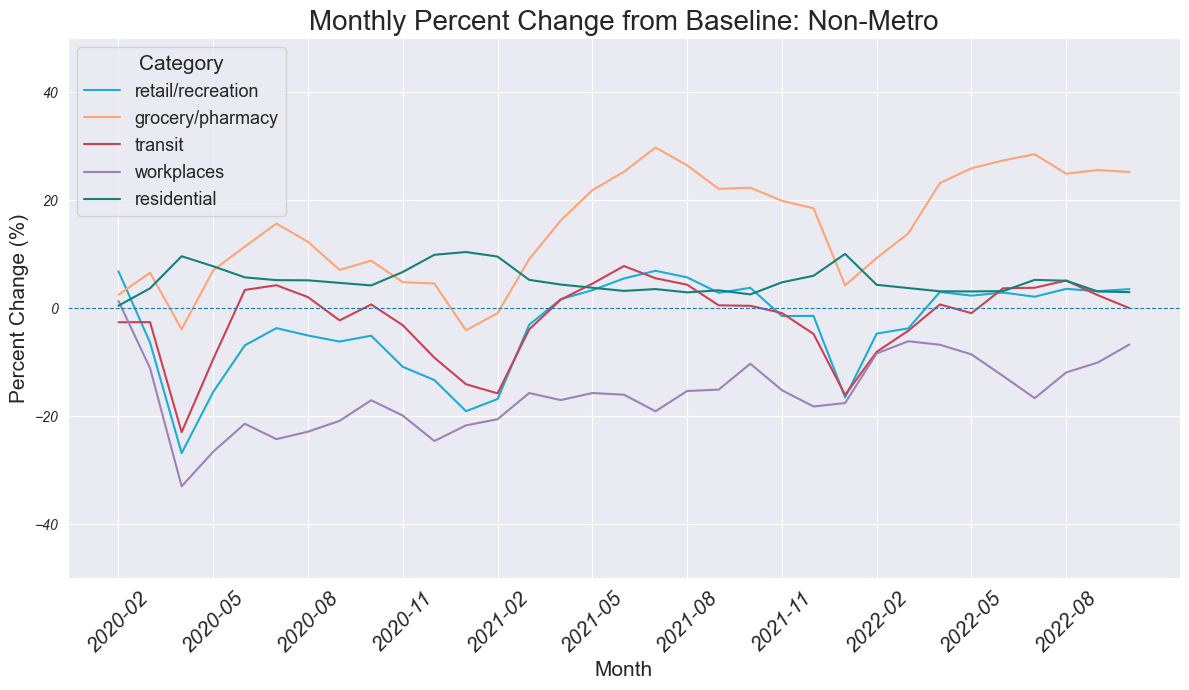

In [14]:


monthly_r = (
    monthly_mob_rural
    .reset_index()
    .melt(id_vars="year_month", value_vars=cat_cols,
          var_name="category", value_name="percent_change")
)
monthly_r['year_month'] = monthly_r['year_month'].dt.strftime("%Y-%m")

monthly_r["category_short"] = monthly_r["category"].replace({
    "retail_and_recreation_percent_change_from_baseline":"retail/recreation", 
    "grocery_and_pharmacy_percent_change_from_baseline":"grocery/pharmacy",  
    "transit_stations_percent_change_from_baseline":"transit", 
    "workplaces_percent_change_from_baseline":"workplaces", 
    "residential_percent_change_from_baseline":"residential"
    }
)


palette = sns.crayon_palette(["Cerulean", "Atomic Tangerine", "Brick Red", "Purple Mountains' Majesty", "Pine Green"])

fig, ax = plt.subplots(figsize=(12, 7))
sns.set_style(style='darkgrid')
sns.lineplot(data=monthly_r, x="year_month", y="percent_change", hue="category_short", palette=palette)
plt.ylim(-50, 50)

plt.title("Monthly Percent Change from Baseline: Non-Metro", fontsize=20)
plt.xlabel("Month", fontsize=15)
plt.ylabel("Percent Change (%)", fontsize=15)
plt.grid(True)
plt.axhline(0, linestyle='--', linewidth=0.8)
ax.legend(title="Category", loc="upper left", fontsize=13, title_fontsize=15)

plt.xticks(rotation=45, fontsize=15, style="italic")
plt.yticks(style="italic")
ax.set_xticks(monthly_r["year_month"].unique()[::3])

plt.tight_layout()
plt.show()

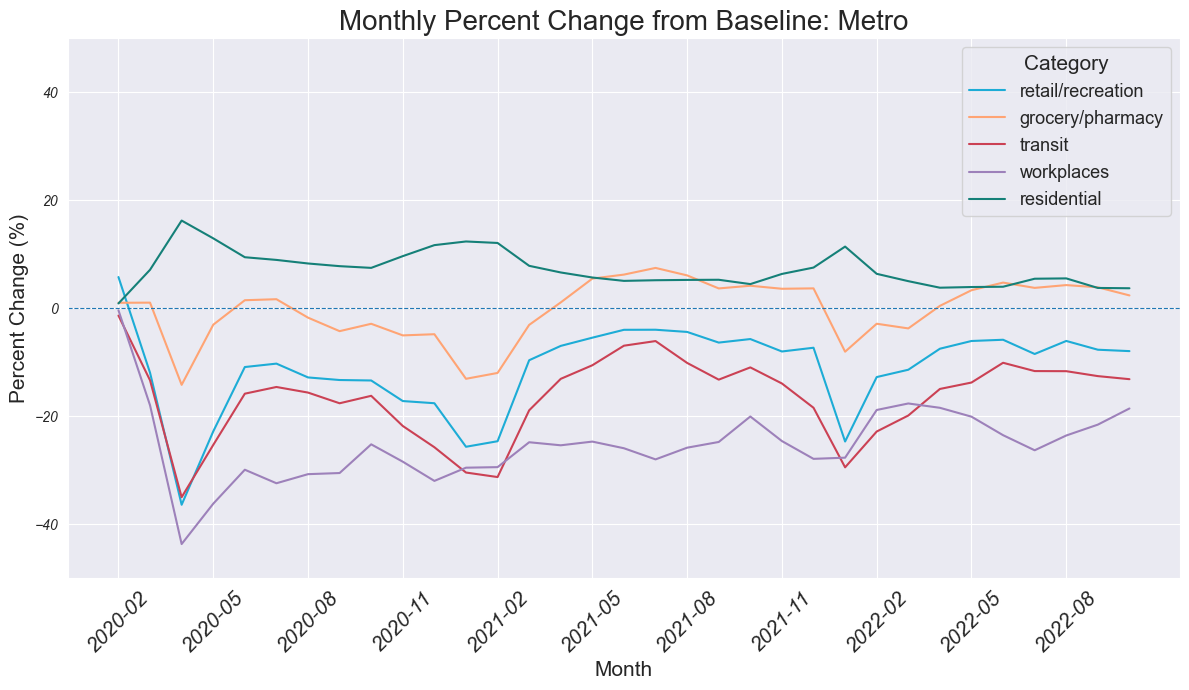

In [15]:

monthly_m = (
    monthly_mob_metro
    .reset_index()
    .melt(id_vars="year_month", value_vars=cat_cols,
          var_name="category", value_name="percent_change")
)

monthly_m["category_short"] = monthly_m["category"].replace({
    "retail_and_recreation_percent_change_from_baseline":"retail/recreation", 
    "grocery_and_pharmacy_percent_change_from_baseline":"grocery/pharmacy",  
    "transit_stations_percent_change_from_baseline":"transit", 
    "workplaces_percent_change_from_baseline":"workplaces", 
    "residential_percent_change_from_baseline":"residential"
    }
)

palette = sns.crayon_palette(["Cerulean", "Atomic Tangerine", "Brick Red", "Purple Mountains' Majesty", "Pine Green"])
monthly_m['year_month'] = monthly_m['year_month'].dt.strftime("%Y-%m")

fig, ax = plt.subplots(figsize=(12, 7))
sns.set_style(style="darkgrid")
sns.lineplot(data=monthly_m, x="year_month", y="percent_change", hue="category_short", palette=palette)
plt.ylim(-50, 50)

plt.title("Monthly Percent Change from Baseline: Metro", fontsize=20)
plt.xlabel("Month", fontsize=15)
plt.ylabel("Percent Change (%)", fontsize=15)
plt.grid(True)
plt.axhline(0, linestyle='--', linewidth=0.8)
ax.legend(title="Category", loc="upper right", fontsize=13, title_fontsize=15)

plt.xticks(rotation=45, fontsize=15, style="italic")
plt.yticks(style="italic")
ax.set_xticks(monthly_m["year_month"].unique()[::3])


plt.tight_layout()
plt.show()

# Justify PCA assumptions

In [ ]:
# 1. linearity: scatterplots

fig, axes = plt.subplots(4, 3)



# PCA

In [37]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [38]:
mobility = pd.read_csv("data/mobility_clean.csv")
mobility['date'] = pd.to_datetime(mobility['date'])
mobility["year_month"] = mobility["date"].dt.to_period('M')

monthly = mobility.groupby(['sub_region_2', 'year_month']).mean().reset_index()

# mobility columns
mobility_feats = [
    'retail_and_recreation_percent_change_from_baseline', 
    'grocery_and_pharmacy_percent_change_from_baseline', 
    'transit_stations_percent_change_from_baseline', 
    'workplaces_percent_change_from_baseline', 
    'residential_percent_change_from_baseline'
]


rural_counties = ["Accomack County","Alleghany County","Bath County",
                  "Bland County","Brunswick County","Buchanan County",
                  "Carroll County","Charlotte County","Craig County",
                  "Dickenson County","Essex County","Grayson County",
                  "Greensville County","Halifax County","Henry County",
                  "Highland County","Lee County","Louisa County",
                  "Lunenburg County","Madison County","Mecklenburg County",
                  "Middlesex County","Montgomery County","Nelson County",
                  "Northampton County","Northumberland County","Patrick County",
                  "Pittsylvania County","Prince Edward County","Pulaski County",
                  "Richmond County","Rockbridge County","Rockingham County",
                  "Russell County","Smyth County","Southampton County",
                  "Tazewell County","Wise County","Wythe County","Shenandoah County"]

mobility['metro_label'] = np.where(mobility['sub_region_2'].isin(rural_counties), 0, 1)
monthly['metro_label'] = np.where(monthly['sub_region_2'].isin(rural_counties), 0, 1)

# checkna
mobility_pca = mobility[mobility_feats]
monthly_pca = monthly[mobility_feats]

print(mobility_pca.isna().sum())
print(monthly_pca.isna().sum())

retail_and_recreation_percent_change_from_baseline    0
grocery_and_pharmacy_percent_change_from_baseline     0
transit_stations_percent_change_from_baseline         0
workplaces_percent_change_from_baseline               0
residential_percent_change_from_baseline              0
dtype: int64
retail_and_recreation_percent_change_from_baseline    0
grocery_and_pharmacy_percent_change_from_baseline     0
transit_stations_percent_change_from_baseline         0
workplaces_percent_change_from_baseline               0
residential_percent_change_from_baseline              0
dtype: int64


In [ ]:
# scale data
scaler = StandardScaler()
monthly_scaled = scaler.fit_transform(monthly_pca)

# initiate pca
pca_m = PCA(n_components=2)

# fit/transform
monthly_result = pca_m.fit_transform(monthly_scaled)

monthly['PC1'] = monthly_result[:,0] # add pc1
monthly['PC2'] = monthly_result[:,1] # add pc2 values

print(pca_m.explained_variance_ratio_)

[0.60341153 0.13633104]


In [ ]:
# visualize
plt.figure(figsize=(10, 6))
sns.set_style(style="darkgrid")
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='metro_label', 
    data=monthly, 
    palette='tab20',
    legend=True
)
plt.title("Scatterplot of PC1 and PC2")

plt.xlabel("PC1")
plt.ylabel("PC2")

In [ ]:
plt.figure(figsize=(12,6))

# Plot each region, coloring by metro status
for (region, metro_label), group in monthly.groupby(['sub_region_2','metro_label']):
    if metro_label == 1:  # Metro
        plt.plot(group['year_month_dt'], group['PC1'], color='lightblue', alpha=0.7)
    else:  # Non-metro
        plt.plot(group['year_month_dt'], group['PC1'], color='crimson', alpha=0.7)

plt.xticks(rotation=45)
plt.ylabel('PC1 (mobility pattern)')
plt.title('PC1 over Time by Region (Metro (gray) vs Non-Metro (red))')
plt.show()

In [ ]:
mob_feats_short = ["retail/rec", "grocery/pharma", "transit", "workplaces", "residential"]
loadings = pd.DataFrame(pca_m.components_.T, 
                        index=mob_feats_short,  # your original categories
                        columns=[f'PC{i+1}' for i in range(len(pca.components_))])


print(loadings['PC1'])

In [ ]:

short_names = {
    'retail_and_recreation_percent_change_from_baseline': 'Retail/Recreation',
    'grocery_and_pharmacy_percent_change_from_baseline': 'Grocery/Pharmacy',
    'transit_stations_percent_change_from_baseline': 'Transit Stations',
    'workplaces_percent_change_from_baseline': 'Workplaces',
    'residential_percent_change_from_baseline': 'Residential'
}
loadings_short = loadings.rename(index=short_names)

monthly['year_month_dt'] = monthly['year_month'].dt.to_timestamp()

# fig with 2 subplots
fig, axes = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]})

# top: pc1 over time
ax = axes[0]
sns.set_style(style="darkgrid")
sns.lineplot(
    data=monthly,
    x='year_month_dt',
    y='PC1',
    hue='metro_label',  # 1=Metro, 0=Rural
    units='sub_region_2',
    estimator=None,
    palette={0: 'crimson', 1: 'lightsteelblue'},
    alpha=0.7,
    ax=ax,
    legend='full'
)

ax.set_ylabel('PC1 (mobility pattern)')
ax.set_xlabel("Month")
ax.set_title('PC1 over Time by Region (Metro vs Non-Metro)')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Metro Label', labels=['Metro', 'Non-Metro'])

# --- Bottom subplot: PC1 loadings ---
ax2 = axes[1]
sns.set_style(style="darkgrid")
sns.barplot(
    x=loadings_short['PC1'].values,
    y=loadings_short['PC1'].index,
    hue=loadings_short['PC1'].index,
    palette='Set2',
    legend=False,
    ax=ax2
)
ax2.set_xlabel('Loading value')
ax2.set_title('PC1 Loadings by Mobility Category')

plt.tight_layout()
plt.show()

In [ ]:
# prep variance explained
expl_var = pca_m.explained_variance_ratio_
cum_var = np.cumsum(expl_var)

# Make a DataFrame for plotting
scree_df = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(expl_var))],
    'Variance': expl_var,
    'Cumulative': cum_var
})

plt.figure(figsize=(6,4))

# Barplot for individual variance
sns.set_style(style="darkgrid")
sns.barplot(x='PC', y='Variance', data=scree_df, color='teal', alpha=0.7)

# Lineplot for cumulative variance
sns.lineplot(x='PC', y='Cumulative', data=scree_df, marker='o', color='crimson')
plt.text(x=0.5, y=0.74, s="Cumulative Variance", color="crimson", fontsize=8)
plt.ylabel('Variance Explained')
plt.title('Scree Plot', fontsize=15)
plt.ylim(0,1.05)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [ ]:

sns.set_style("ticks")
plt.figure(figsize=(10, 7))
cols = ["rosybrown", "lightsteelblue"]

sns.scatterplot(
    x='PC1', y='PC2', 
    hue='metro_label', palette=cols, 
    data=monthly, 
    alpha=0.7
)

for i in range(loadings.shape[0]): 
    plt.arrow(0, 0, loadings.PC1[i]*3, loadings.PC2[i]*3, 
              color='black', alpha=0.7, head_width=0.1)
    plt.text(loadings.PC1[i]*3.3, loadings.PC2[i]*3.3, loadings.index[i], 
             color='black', fontsize=12)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of County-Month Mobility Data\nArrows show feature contributions')
plt.legend(title='nonmetro = 0 / metro = 1')
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))
sns.set_style(style="darkgrid")
sns.barplot(
    x=loadings['PC1'].values,
    y=loadings['PC1'].index,
    hue=loadings['PC1'].index,
    palette='Set2',
    legend=False
)
ax2.set_xlabel('Loading value')
ax2.set_title('PC1 Loadings by Mobility Category')
plt.ylabel("Mobility Category")
plt.title("PC1 Loadings", fontsize=15)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

# Permutation test

In [ ]:
monthly1 = pd.read_csv("data/monthly.csv")

In [ ]:
# Defining the funtion

# separate groups
group_m = monthly.loc[monthly['metro_label'] == 1, 'PC1'].to_numpy(dtype=float)
group_nm = monthly.loc[monthly['metro_label'] == 0, 'PC1'].to_numpy(dtype=float)

np.random.seed(42) # seed

def permutation_test(group_a, group_b, num_permutations=10000): 
    """
    Permutation test for average PC1 scores

    Args: 
        group_a: numpy array-like  object with scores for first group
        group_a: numpy array-like  object with scores for second group
        num_permutations (int): number of permutations

    Returns: 
        p-value 
    """
    group_a = np.array(group_a) # convert to groups
    group_b = np.array(group_b)

    n_a = len(group_a)
    combined = np.concatenate((group_a, group_b))
    observed_diff = np.mean(group_a) - np.mean(group_b)

    count = 0

    for _ in range(num_permutations):
        perm = np.random.permutation(combined)
        perm_diff = np.mean(perm[:n_a]) - np.mean(perm[n_a:])
                
        if np.abs(perm_diff) >= np.abs(observed_diff):
            count += 1
                    
    # Include the observed case in the calculation (+1)
    return (count + 1) / (num_permutations + 1)


p_value = permutation_test(group_m, group_nm)
print(p_value)

In [ ]:
observed_diff = np.mean(group_m) - np.mean(group_nm)
print(observed_diff)

n_perms = 10000
diffs = np.zeros(n_perms)

all_pc1 = monthly['PC1'].values
metro_i = monthly['metro_label'] == 1
n_metro = sum(metro_i)

for i in range(n_perms): 
    perms = np.random.permutation(all_pc1)

    perm_metro = perms[:n_metro]
    perm_non = perms[n_metro:]

    diffs[i] = np.mean(perm_metro) - np.mean(perm_non)

p_val = np.mean(np.abs(diffs) >= np.abs(observed_diff))
print(p_val)


In [ ]:
sns.set_style("darkgrid")
plt.figure(figsize=(10, 6))
sns.histplot(diffs, bins=40, alpha=0.5, label='Permutation distribution', 
             linewidth=0.5)
plt.axvline(observed_diff, color='red', linestyle='dashed', linewidth=2, 
            label=f'Observed difference: {observed_diff:.4f}')

plt.axvline(-observed_diff, color='red', linestyle='dashed', linewidth=2)

plt.title(f'Permutation Test: Metro vs Non-Metro PC1 Scores\np-value = {p_value:.4f}', fontsize=15)
plt.xlabel('Difference in means', fontsize=13)
plt.ylabel('Frequency', fontsize=13)
plt.legend()
plt.show()